# Lateral Movement Detection: Rule-Based vs Graph-Based

This notebook downloads the synthetic authentication dataset from Kaggle
(`danielpeng1995/synthetic-enterprise-auth-logs`), runs both detection methods, and reports independently calculated precision, recall, false-positive rate, and confusion matrices.

**1. Load the dataset**  
180,000 authentication events, 498 active users, 150 hosts, and 16,391 labeled MITRE ATT&CK T1078/T1021 attack chains.

**2. Rule-based detector**  
Flags new user-to-host connections and previously unseen source subnets.

**3. Graph-based detector**  
Uses edge novelty, path rarity, and host degree deviation, combined with logistic regression.

**4. Independent evaluation**  
Both methods are evaluated on a held-out test period using the same alert budget for a fair side-by-side comparison.


In [ ]:
from collections import defaultdict
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve,
)

dataset_path = Path(
    kagglehub.dataset_download(
        "danielpeng1995/synthetic-enterprise-auth-logs"
    )
)

df = pd.read_csv(
    dataset_path / "synthetic_auth_events_180000.csv"
)

print(f"Loaded {len(df):,} authentication events")
df.head()


## 1. Prepare and summarize the dataset

The timestamps and Boolean labels are converted to analysis-ready formats, after which the events are ordered chronologically.


In [ ]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="mixed",
    errors="raise",
)

for column in ["is_malicious", "is_domain_controller_target"]:
    if not pd.api.types.is_bool_dtype(df[column]):
        df[column] = (
            df[column]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"true": True, "false": False})
        )

df = (
    df.sort_values(["timestamp", "event_id"])
    .drop_duplicates(subset=["event_id"])
    .reset_index(drop=True)
)

df["day"] = (
    df["timestamp"] - df["timestamp"].min()
).dt.days

summary = pd.DataFrame(
    {
        "Measure": [
            "Events",
            "Users",
            "Source hosts",
            "Destination hosts",
            "Benign events",
            "Malicious events",
            "Attack chains",
            "Start time",
            "End time",
        ],
        "Observed value": [
            f"{len(df):,}",
            f"{df['user_id'].nunique():,}",
            f"{df['src_host'].nunique():,}",
            f"{df['dst_host'].nunique():,}",
            f"{(~df['is_malicious']).sum():,}",
            f"{df['is_malicious'].sum():,}",
            f"{df['attack_chain_id'].nunique(dropna=True):,}",
            str(df["timestamp"].min()),
            str(df["timestamp"].max()),
        ],
    }
)

display(summary)


## 2. Time-ordered experimental design

The data is divided chronologically:

- **Baseline period:** days 0 through 6, used to learn normal user-host and user-subnet history
- **Fit period:** days 7 through 14, used to estimate graph-model coefficients
- **Test period:** days 15 through 29, used only for final evaluation

The model is not randomly split because future authentication activity should not be used to explain earlier events.


In [ ]:
BASELINE_END = df["timestamp"].min() + pd.Timedelta(days=7)
FIT_END = df["timestamp"].min() + pd.Timedelta(days=15)

baseline_df = df[df["timestamp"] < BASELINE_END].copy()
fit_df = df[
    (df["timestamp"] >= BASELINE_END) & (df["timestamp"] < FIT_END)
].copy()
test_df = df[df["timestamp"] >= FIT_END].copy()

split_summary = pd.DataFrame(
    [
        {
            "Period": "Baseline",
            "Events": len(baseline_df),
            "Benign": int((~baseline_df["is_malicious"]).sum()),
            "Malicious": int(baseline_df["is_malicious"].sum()),
            "Start": baseline_df["timestamp"].min(),
            "End": baseline_df["timestamp"].max(),
        },
        {
            "Period": "Fit",
            "Events": len(fit_df),
            "Benign": int((~fit_df["is_malicious"]).sum()),
            "Malicious": int(fit_df["is_malicious"].sum()),
            "Start": fit_df["timestamp"].min(),
            "End": fit_df["timestamp"].max(),
        },
        {
            "Period": "Test",
            "Events": len(test_df),
            "Benign": int((~test_df["is_malicious"]).sum()),
            "Malicious": int(test_df["is_malicious"].sum()),
            "Start": test_df["timestamp"].min(),
            "End": test_df["timestamp"].max(),
        },
    ]
)

display(split_summary)


,Period,Events,Benign,Malicious,Start,End
0,Baseline,42000,42000,0,2026-05-01 00:00:00,2026-05-07 23:59:39
1,Fit,48000,25440,22560,2026-05-08 00:00:11,2026-05-15 23:59:39
2,Test,90000,47700,42300,2026-05-16 00:00:26,2026-05-30 23:59:59


## 3. Rule-based baseline

The baseline flags an authentication event when at least one of the following is true:

- the destination host has not previously been observed for that user
- the source subnet has not previously been observed for that user

Observed relationships are updated in chronological order after each event.


In [ ]:
def score_novelty(score_df, seen_hosts, seen_subnets):
    new_host_flags = []
    new_subnet_flags = []

    for row in score_df.itertuples():
        new_host = row.dst_host not in seen_hosts[row.user_id]
        new_subnet = row.src_subnet not in seen_subnets[row.user_id]

        new_host_flags.append(new_host)
        new_subnet_flags.append(new_subnet)

        seen_hosts[row.user_id].add(row.dst_host)
        seen_subnets[row.user_id].add(row.src_subnet)

    return np.asarray(new_host_flags), np.asarray(new_subnet_flags)


seen_hosts = defaultdict(set)
seen_subnets = defaultdict(set)

for row in baseline_df.itertuples():
    seen_hosts[row.user_id].add(row.dst_host)
    seen_subnets[row.user_id].add(row.src_subnet)

new_host_fit, new_subnet_fit = score_novelty(
    fit_df, seen_hosts, seen_subnets
)
new_host_test, new_subnet_test = score_novelty(
    test_df, seen_hosts, seen_subnets
)

rule_flags_test = new_host_test | new_subnet_test

print("Rule-based test alerts:", f"{int(rule_flags_test.sum()):,}")


Rule-based test alerts: 32,013


## 4. Graph-based features

The graph-based detector uses three features:

- **N, edge novelty:** whether the user-to-destination relationship is new
- **R, path rarity:** whether the destination is closer to `DC-01` than the user's historical host footprint
- **D, degree deviation:** positive deviation in the destination host's daily distinct-user count

The degree-deviation feature is a daily batch statistic. It should not be interpreted as a fully real-time feature.


In [ ]:
DC_HOST = "DC-01"


def build_host_graph(history_df):
    graph = nx.Graph()
    graph.add_nodes_from(
        pd.unique(history_df[["src_host", "dst_host"]].values.ravel())
    )

    destinations_by_user = history_df.groupby("user_id")["dst_host"].apply(
        lambda values: sorted(set(values))
    )

    for hosts in destinations_by_user:
        for left_index in range(len(hosts)):
            for right_index in range(left_index + 1, len(hosts)):
                graph.add_edge(hosts[left_index], hosts[right_index])

    return graph


def distances_to_domain_controller(graph):
    if DC_HOST not in graph:
        return defaultdict(lambda: 99)

    return defaultdict(
        lambda: 99,
        nx.single_source_shortest_path_length(graph, DC_HOST),
    )


def user_minimum_historical_distance(history_df, distance_map):
    user_footprints = history_df.groupby("user_id")["dst_host"].apply(set)
    return {
        user_id: min(
            (distance_map[host] for host in hosts),
            default=99,
        )
        for user_id, hosts in user_footprints.items()
    }


def host_daily_reference(history_df):
    daily_counts = (
        history_df.groupby(["dst_host", "day"])["user_id"]
        .nunique()
        .reset_index(name="distinct_users")
    )

    host_stats = (
        daily_counts.groupby("dst_host")["distinct_users"]
        .agg(["mean", "std"])
        .fillna(0)
    )

    return host_stats["mean"].to_dict(), host_stats["std"].to_dict()


def compute_path_and_degree_features(
    score_df,
    distance_map,
    user_min_distance,
    host_mean,
    host_std,
):
    path_rarity = []
    degree_deviation = []

    daily_actual = (
        score_df.groupby(["dst_host", "day"])["user_id"]
        .nunique()
        .to_dict()
    )

    for row in score_df.itertuples():
        destination_distance = distance_map[row.dst_host]
        historical_minimum = user_min_distance.get(row.user_id, 99)

        path_rarity.append(
            1.0 if destination_distance < historical_minimum else 0.0
        )

        actual = daily_actual.get((row.dst_host, row.day), 1)
        expected_mean = host_mean.get(row.dst_host, actual)
        expected_std = host_std.get(row.dst_host, 0.0)

        z_score = (actual - expected_mean) / (expected_std + 0.5)
        degree_deviation.append(max(0.0, z_score))

    return np.asarray(path_rarity), np.asarray(degree_deviation)


In [ ]:
baseline_graph = build_host_graph(baseline_df)
baseline_distances = distances_to_domain_controller(baseline_graph)
baseline_user_distances = user_minimum_historical_distance(
    baseline_df, baseline_distances
)
baseline_host_mean, baseline_host_std = host_daily_reference(baseline_df)

R_fit, D_fit = compute_path_and_degree_features(
    fit_df,
    baseline_distances,
    baseline_user_distances,
    baseline_host_mean,
    baseline_host_std,
)
N_fit = new_host_fit.astype(float)

history_before_test = pd.concat(
    [baseline_df, fit_df],
    ignore_index=True,
)

test_graph = build_host_graph(history_before_test)
test_distances = distances_to_domain_controller(test_graph)
test_user_distances = user_minimum_historical_distance(
    history_before_test, test_distances
)
test_host_mean, test_host_std = host_daily_reference(history_before_test)

R_test, D_test = compute_path_and_degree_features(
    test_df,
    test_distances,
    test_user_distances,
    test_host_mean,
    test_host_std,
)
N_test = new_host_test.astype(float)

X_fit = np.column_stack([N_fit, R_fit, D_fit])
y_fit = fit_df["is_malicious"].to_numpy(dtype=bool)

X_test = np.column_stack([N_test, R_test, D_test])
y_test = test_df["is_malicious"].to_numpy(dtype=bool)

feature_summary = pd.DataFrame(
    {
        "Feature": ["N: edge novelty", "R: path rarity", "D: degree deviation"],
        "Fit mean": X_fit.mean(axis=0),
        "Test mean": X_test.mean(axis=0),
    }
)

display(feature_summary)


,Feature,Fit mean,Test mean
0,N: edge novelty,0.214500,0.214500
1,R: path rarity,0.214500,0.214500
2,D: degree deviation,8.017776,12.630087


## 5. Fit the graph-based model

Logistic regression estimates the contribution of the three graph features using only the fit period. Class weighting is applied because benign and malicious observations may not be equally represented.


In [ ]:
graph_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=0,
)
graph_model.fit(X_fit, y_fit)

fit_scores = graph_model.predict_proba(X_fit)[:, 1]
test_scores = graph_model.predict_proba(X_test)[:, 1]

coefficient_table = pd.DataFrame(
    {
        "Feature": ["N: edge novelty", "R: path rarity", "D: degree deviation"],
        "Coefficient": graph_model.coef_[0],
    }
)

display(coefficient_table)
print("Intercept:", round(float(graph_model.intercept_[0]), 6))


,Feature,Coefficient
0,N: edge novelty,1.571732
1,R: path rarity,1.571732
2,D: degree deviation,0.091168


Intercept: -1.373835


## 6. Primary evaluation: equal analyst-review budget

The rule-based detector determines the number of alerts in the test period. The graph-based detector then flags the same number of highest-scoring test events.

This thresholding procedure uses test scores and the baseline's alert count, but it does not use test labels. Both methods therefore consume the same analyst-review capacity.


In [ ]:
number_of_rule_alerts = int(rule_flags_test.sum())

# Deterministic ranking, including a stable tie-break by row position.
ranked_indices = np.lexsort(
    (
        np.arange(len(test_scores)),
        -np.round(test_scores, 12),
    )
)

graph_flags_matched = np.zeros(len(test_scores), dtype=bool)
graph_flags_matched[ranked_indices[:number_of_rule_alerts]] = True

matched_graph_threshold = float(
    test_scores[ranked_indices[number_of_rule_alerts - 1]]
)

print("Alert budget:", f"{number_of_rule_alerts:,}")
print("Matched graph threshold:", round(matched_graph_threshold, 6))


Alert budget: 32,013
Matched graph threshold: 0.854965


In [ ]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def evaluate_detector(y_true, flags, method):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        flags,
        labels=[False, True],
    ).ravel()

    return {
        "Method": method,
        "Precision": safe_divide(tp, tp + fp),
        "Recall": safe_divide(tp, tp + fn),
        "FPR": safe_divide(fp, fp + tn),
        "Specificity": safe_divide(tn, tn + fp),
        "Accuracy": safe_divide(tp + tn, tp + tn + fp + fn),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "Alerts": int(np.sum(flags)),
    }


rule_metrics = evaluate_detector(
    y_test,
    rule_flags_test,
    "Rule-Based",
)
graph_metrics = evaluate_detector(
    y_test,
    graph_flags_matched,
    "Graph-Based",
)

results = pd.DataFrame([rule_metrics, graph_metrics])
display(
    results[
        [
            "Method",
            "Precision",
            "Recall",
            "FPR",
            "Specificity",
            "Accuracy",
            "TP",
            "FP",
            "FN",
            "TN",
            "Alerts",
        ]
    ].round(4)
)


,Method,Precision,Recall,FPR,Specificity,Accuracy,TP,FP,FN,TN,Alerts
0,Rule-Based,0.6871,0.5200,0.210,0.790,0.6631,21996,10017,20304,37683,32013
1,Graph-Based,0.8227,0.6226,0.119,0.881,0.7595,26336,5677,15964,42023,32013


### Rule-based confusion matrix

Rows are actual classes and columns are predicted classes.


,Predicted benign,Predicted malicious
Actual benign,37683,10017
Actual malicious,20304,21996


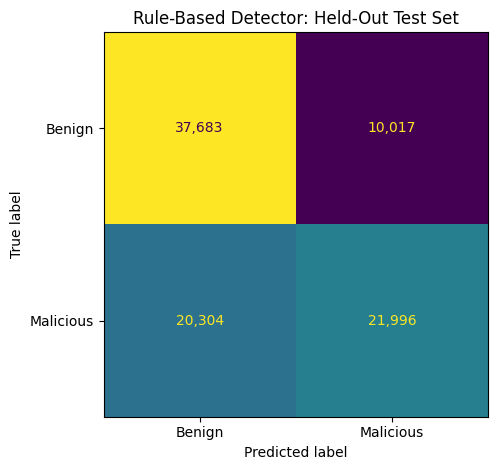

In [ ]:
rule_cm = confusion_matrix(
    y_test,
    rule_flags_test,
    labels=[False, True],
)

rule_cm_table = pd.DataFrame(
    rule_cm,
    index=["Actual benign", "Actual malicious"],
    columns=["Predicted benign", "Predicted malicious"],
)

display(rule_cm_table)

display_object = ConfusionMatrixDisplay(
    confusion_matrix=rule_cm,
    display_labels=["Benign", "Malicious"],
)
display_object.plot(values_format=",d", colorbar=False)
plt.title("Rule-Based Detector: Held-Out Test Set")
plt.tight_layout()
plt.show()


### Graph-based confusion matrix

The graph-based detector uses the same total number of alerts as the rule-based detector.


,Predicted benign,Predicted malicious
Actual benign,42023,5677
Actual malicious,15964,26336


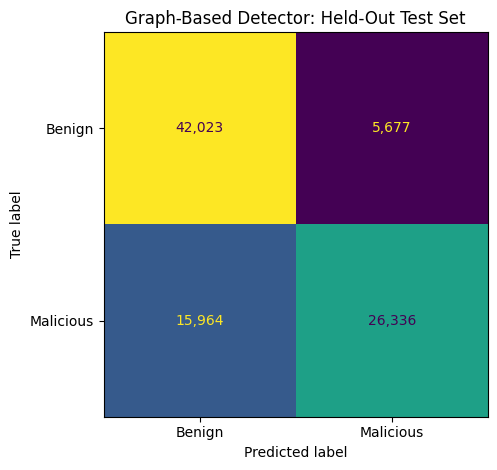

In [ ]:
graph_cm = confusion_matrix(
    y_test,
    graph_flags_matched,
    labels=[False, True],
)

graph_cm_table = pd.DataFrame(
    graph_cm,
    index=["Actual benign", "Actual malicious"],
    columns=["Predicted benign", "Predicted malicious"],
)

display(graph_cm_table)

display_object = ConfusionMatrixDisplay(
    confusion_matrix=graph_cm,
    display_labels=["Benign", "Malicious"],
)
display_object.plot(values_format=",d", colorbar=False)
plt.title("Graph-Based Detector: Held-Out Test Set")
plt.tight_layout()
plt.show()


## 7. Sensitivity analysis: threshold selected from the fit period

The primary experiment matches alert volume because that is the fairest fixed-budget comparison. This secondary analysis asks how the graph detector performs when its threshold is selected only from the fit period by maximizing F1 and then frozen before test evaluation.

This is not compared with any predetermined target.


In [ ]:
fit_precision, fit_recall, fit_thresholds = precision_recall_curve(
    y_fit,
    fit_scores,
)

fit_f1 = (
    2 * fit_precision * fit_recall
    / (fit_precision + fit_recall + 1e-12)
)

best_index = int(np.nanargmax(fit_f1[:-1]))
fit_selected_threshold = float(fit_thresholds[best_index])

graph_flags_fit_selected = test_scores >= fit_selected_threshold

fit_selected_metrics = evaluate_detector(
    y_test,
    graph_flags_fit_selected,
    "Graph-Based, fit-selected threshold",
)

sensitivity_results = pd.DataFrame(
    [
        rule_metrics,
        graph_metrics,
        fit_selected_metrics,
    ]
)

print("Fit-selected threshold:", round(fit_selected_threshold, 6))
print("Fit-period F1:", round(float(fit_f1[best_index]), 6))

display(
    sensitivity_results[
        [
            "Method",
            "Precision",
            "Recall",
            "FPR",
            "TP",
            "FP",
            "FN",
            "TN",
            "Alerts",
        ]
    ].round(4)
)


Fit-selected threshold: 0.762269
Fit-period F1: 0.811123


,Method,Precision,Recall,FPR,TP,FP,FN,TN,Alerts
0,Rule-Based,0.6871,0.5200,0.210,21996,10017,20304,37683,32013
1,Graph-Based,0.8227,0.6226,0.119,26336,5677,15964,42023,32013
2,"Graph-Based, fit-selected threshold",0.8334,0.7900,0.140,33417,6678,8883,41022,40095


## 8. Attack-focused diagnostics

Event-level metrics do not show whether an attack chain was detected at least once. This section reports:

- recall by MITRE ATT&CK technique
- percentage of test-period attack chains with at least one alert
- recall for malicious events targeting the domain controller


In [ ]:
diagnostic_df = test_df[
    [
        "is_malicious",
        "attack_chain_id",
        "mitre_technique",
        "is_domain_controller_target",
    ]
].copy()

diagnostic_df["Rule-Based alert"] = rule_flags_test
diagnostic_df["Graph-Based alert"] = graph_flags_matched

malicious_test = diagnostic_df[diagnostic_df["is_malicious"]].copy()

technique_rows = []
for technique, group in malicious_test.groupby("mitre_technique", dropna=False):
    technique_rows.append(
        {
            "MITRE technique": technique,
            "Malicious events": len(group),
            "Rule-Based recall": group["Rule-Based alert"].mean(),
            "Graph-Based recall": group["Graph-Based alert"].mean(),
        }
    )

technique_results = pd.DataFrame(technique_rows)
display(technique_results.round(4))

chain_alerts = (
    malicious_test.dropna(subset=["attack_chain_id"])
    .groupby("attack_chain_id")[
        ["Rule-Based alert", "Graph-Based alert"]
    ]
    .any()
)

chain_summary = pd.DataFrame(
    {
        "Method": ["Rule-Based", "Graph-Based"],
        "Attack chains detected": [
            int(chain_alerts["Rule-Based alert"].sum()),
            int(chain_alerts["Graph-Based alert"].sum()),
        ],
        "Total attack chains": [
            len(chain_alerts),
            len(chain_alerts),
        ],
        "Chain detection rate": [
            chain_alerts["Rule-Based alert"].mean(),
            chain_alerts["Graph-Based alert"].mean(),
        ],
    }
)

display(chain_summary.round(4))

dc_malicious = malicious_test[
    malicious_test["is_domain_controller_target"]
]

dc_results = pd.DataFrame(
    {
        "Method": ["Rule-Based", "Graph-Based"],
        "Malicious DC-target events": [
            len(dc_malicious),
            len(dc_malicious),
        ],
        "Detected": [
            int(dc_malicious["Rule-Based alert"].sum()),
            int(dc_malicious["Graph-Based alert"].sum()),
        ],
        "Recall": [
            dc_malicious["Rule-Based alert"].mean(),
            dc_malicious["Graph-Based alert"].mean(),
        ],
    }
)

display(dc_results.round(4))


,MITRE technique,Malicious events,Rule-Based recall,Graph-Based recall
0,T1021,31620,0.5196,0.6220
1,T1078,10680,0.5212,0.6243


,Method,Attack chains detected,Total attack chains,Chain detection rate
0,Rule-Based,10054,10680,0.9414
1,Graph-Based,10399,10680,0.9737


,Method,Malicious DC-target events,Detected,Recall
0,Rule-Based,215,215,1.0000
1,Graph-Based,215,141,0.6558


## 9. Data-driven interpretation

The statements below are generated from the observed test results. They are not predetermined conclusions.


In [ ]:
rule_row = results.loc[results["Method"] == "Rule-Based"].iloc[0]
graph_row = results.loc[results["Method"] == "Graph-Based"].iloc[0]

precision_change = graph_row["Precision"] - rule_row["Precision"]
recall_change = graph_row["Recall"] - rule_row["Recall"]
fpr_change = graph_row["FPR"] - rule_row["FPR"]

print(
    f"Both methods generated {int(rule_row['Alerts']):,} alerts in the held-out test set."
)
print(
    f"Graph-based precision changed by {precision_change:+.3f} "
    f"relative to the rule-based baseline."
)
print(
    f"Graph-based recall changed by {recall_change:+.3f} "
    f"relative to the rule-based baseline."
)
print(
    f"Graph-based false-positive rate changed by {fpr_change:+.3f} "
    f"relative to the rule-based baseline."
)

if (
    graph_row["Precision"] > rule_row["Precision"]
    and graph_row["Recall"] > rule_row["Recall"]
    and graph_row["FPR"] < rule_row["FPR"]
):
    print(
        "Observed conclusion: under the equal-alert budget, the graph-based "
        "detector outperformed the simple rule-based baseline on precision, "
        "recall, and false-positive rate for this dataset."
    )
else:
    print(
        "Observed conclusion: the graph-based detector did not improve every "
        "reported metric under the equal-alert budget for this dataset."
    )


Both methods generated 32,013 alerts in the held-out test set.
Graph-based precision changed by +0.136 relative to the rule-based baseline.
Graph-based recall changed by +0.103 relative to the rule-based baseline.
Graph-based false-positive rate changed by -0.091 relative to the rule-based baseline.
Observed conclusion: under the equal-alert budget, the graph-based detector outperformed the simple rule-based baseline on precision, recall, and false-positive rate for this dataset.


## 10. Scope and limitations

- This is a synthetic dataset with authored attack behavior and ground-truth labels.
- The evaluation compares the graph model with a deliberately simple two-rule baseline, not a modern commercial UEBA system.
- The graph model's coefficients are supervised because they are estimated using labeled fit-period events.
- Degree deviation is computed as a daily batch feature and is not fully real-time.
- This notebook evaluates one published dataset. It does not justify mean plus or minus standard deviation across multiple independently generated datasets.
- The results demonstrate behavior within this controlled simulation and should not be treated as validated real-world performance.
